In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
MEANS = [-1.0, 0.0, 1.0]
STD_DEV = 0.05

BATCH_SIZE = 512
N_STEPS = 50
N_EPOCHS = 5000
LR = 1e-3

N_SAMPLES = 5000 

MODE_THRESHOLD = 1 * STD_DEV     
DEAD_ZONE_THRESHOLD = 3 * STD_DEV 

In [3]:
print("PHASE 1: GEOMETRIC BASELINE CALIBRATION")

print(f"Means: {MEANS}")
print(f"Std Dev: {STD_DEV}")
print(f"Mode Region: |x - μ| < {MODE_THRESHOLD}")
print(f"Dead Zone: |x - μ| > {DEAD_ZONE_THRESHOLD}")
print(f"Transition Zone: {MODE_THRESHOLD} < |x - μ| < {DEAD_ZONE_THRESHOLD}")

PHASE 1: GEOMETRIC BASELINE CALIBRATION
Means: [-1.0, 0.0, 1.0]
Std Dev: 0.05
Mode Region: |x - μ| < 0.05
Dead Zone: |x - μ| > 0.15000000000000002
Transition Zone: 0.05 < |x - μ| < 0.15000000000000002


In [4]:
def get_region(x, return_distance=False):

    min_dist = min(abs(x - m) for m in MEANS)
    
    if min_dist < MODE_THRESHOLD:
        region = "Mode"
    elif min_dist > DEAD_ZONE_THRESHOLD:
        region = "DeadZone"
    else:
        region = "Transition"
    
    if return_distance:
        return region, min_dist
    return region

In [5]:
def get_batch(batch_size):
    indices = torch.randint(0, 3, (batch_size,))
    means = torch.tensor(MEANS)[indices].float()
    data = torch.normal(means, STD_DEV)
    return data.unsqueeze(1)

In [6]:
class SimpleDiffusionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.Mish(),
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x, t):
        t_input = (t.view(-1, 1) / N_STEPS) * 2 - 1
        inp = torch.cat([x, t_input], dim=1)
        return self.net(inp)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nTraining on: {device}")

model = SimpleDiffusionNet().to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, total_steps=N_EPOCHS)

betas = torch.linspace(1e-4, 0.02, N_STEPS).to(device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

print(f"Training for {N_EPOCHS} epochs...")
for epoch in tqdm(range(N_EPOCHS), desc="Training"):
    optimizer.zero_grad()
    x0 = get_batch(BATCH_SIZE).to(device)
    t = torch.randint(0, N_STEPS, (BATCH_SIZE,)).to(device)
    noise = torch.randn_like(x0)
    
    a_bar = alphas_cumprod[t].view(-1, 1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise
    
    noise_pred = model(xt, t)
    loss = nn.MSELoss()(noise_pred, noise)
    
    loss.backward()
    optimizer.step()
    scheduler.step()

print("Training complete!\n")


Training on: cuda
Training for 5000 epochs...


Training: 100%|██████████| 5000/5000 [00:12<00:00, 412.36it/s]

Training complete!



In [8]:
print(f"Generating {N_SAMPLES} samples with trajectory tracking...")
model.eval()

xt = torch.randn(N_SAMPLES, 1).to(device)
trajectory_stack = []

with torch.no_grad():
    for i in reversed(range(N_STEPS)):
        t = torch.full((N_SAMPLES,), i, dtype=torch.long).to(device)
        noise_pred = model(xt, t)
        
        a_bar = alphas_cumprod[t].view(-1, 1)
        x0_pred = (xt - torch.sqrt(1 - a_bar) * noise_pred) / torch.sqrt(a_bar)
        
        trajectory_stack.append(x0_pred.cpu().float().numpy())
        
        if i > 0:
            noise = torch.randn_like(xt)
            beta = betas[t].view(-1, 1)
            alpha = alphas[t].view(-1, 1)
            xt = (xt - (beta / torch.sqrt(1 - a_bar)) * noise_pred) / torch.sqrt(alpha) + torch.sqrt(beta) * noise
        else:
            xt = x0_pred

trajectories = np.array(trajectory_stack).transpose(1, 0, 2).squeeze()
final_samples = trajectories[:, -1]

print("Sampling complete!\n")

Generating 5000 samples with trajectory tracking...
Sampling complete!



In [10]:
print("PILOT STUDY: Testing Different Variance Windows")

window_configs = [
    ("Last 15 steps (Spec)", N_STEPS - 15, N_STEPS),
    ("Last 20 steps", N_STEPS - 20, N_STEPS),
    ("Last 10 steps", N_STEPS - 10, N_STEPS),
    ("Middle 20 steps", N_STEPS//2 - 10, N_STEPS//2 + 10),
    ("First 15 steps", 0, 15),
]

results = []

for window_name, start_idx, end_idx in window_configs:
    variances = np.var(trajectories[:, start_idx:end_idx].astype(np.float32), axis=1)
    
    mode_vars = []
    dead_vars = []
    transition_vars = []
    
    for i, x in enumerate(final_samples):
        region = get_region(x)
        if region == "Mode":
            mode_vars.append(variances[i])
        elif region == "DeadZone":
            dead_vars.append(variances[i])
        else: 
            transition_vars.append(variances[i])
    
    if len(mode_vars) > 0 and len(dead_vars) > 0:
        mean_mode_var = np.mean(mode_vars)
        mean_dead_var = np.mean(dead_vars)
        ratio = mean_dead_var / mean_mode_var if mean_mode_var > 0 else 0
    else:
        ratio = 0
        mean_mode_var = np.mean(mode_vars) if mode_vars else 0
        mean_dead_var = np.mean(dead_vars) if dead_vars else 0
    
    results.append({
        'name': window_name,
        'ratio': ratio,
        'n_mode': len(mode_vars),
        'n_dead': len(dead_vars),
        'n_transition': len(transition_vars),
        'mean_mode_var': mean_mode_var,
        'mean_dead_var': mean_dead_var,
        'variances': variances,
        'mode_vars': mode_vars,
        'dead_vars': dead_vars
    })
    
    print(f"\n{window_name} (steps {start_idx}-{end_idx}):")
    print(f"  Mode samples: {len(mode_vars)}")
    print(f"  Dead Zone samples: {len(dead_vars)}")
    print(f"  Transition samples: {len(transition_vars)}")
    print(f"  Mean variance (Mode): {mean_mode_var:.6f}")
    print(f"  Mean variance (Dead): {mean_dead_var:.6f}")
    print(f"  RATIO: {ratio:.2f} {'PASS' if ratio > 5.0 else 'FAIL'}")

PILOT STUDY: Testing Different Variance Windows

Last 15 steps (Spec) (steps 35-50):
  Mode samples: 3166
  Dead Zone samples: 49
  Transition samples: 1785
  Mean variance (Mode): 0.001408
  Mean variance (Dead): 0.022730
  RATIO: 16.14 PASS

Last 20 steps (steps 30-50):
  Mode samples: 3166
  Dead Zone samples: 49
  Transition samples: 1785
  Mean variance (Mode): 0.005369
  Mean variance (Dead): 0.030094
  RATIO: 5.61 PASS

Last 10 steps (steps 40-50):
  Mode samples: 3166
  Dead Zone samples: 49
  Transition samples: 1785
  Mean variance (Mode): 0.000429
  Mean variance (Dead): 0.007077
  RATIO: 16.50 PASS

Middle 20 steps (steps 15-35):
  Mode samples: 3166
  Dead Zone samples: 49
  Transition samples: 1785
  Mean variance (Mode): 0.027069
  Mean variance (Dead): 0.034227
  RATIO: 1.26 FAIL

First 15 steps (steps 0-15):
  Mode samples: 3166
  Dead Zone samples: 49
  Transition samples: 1785
  Mean variance (Mode): 0.023721
  Mean variance (Dead): 0.029122
  RATIO: 1.23 FAIL


In [12]:
best_result = max(results, key=lambda x: x['ratio'])
print(f"BEST WINDOW: {best_result['name']}")
print(f"BEST RATIO: {best_result['ratio']:.2f}")

if best_result['ratio'] > 5.0:
    print("PHASE 1 PASSED - Metric is valid!")
else:
    print("NONE")

BEST WINDOW: Last 10 steps
BEST RATIO: 16.50
PHASE 1 PASSED - Metric is valid!


In [13]:
print("DIAGNOSTIC ANALYSIS")

print("\n1. Generated Distribution:")
print(f"   Mean: {np.mean(final_samples):.4f}")
print(f"   Std: {np.std(final_samples):.4f}")
print(f"   Min: {np.min(final_samples):.4f}")
print(f"   Max: {np.max(final_samples):.4f}")

regions = [get_region(x) for x in final_samples]
print(f"\n2. Region Distribution:")
print(f"   Mode: {regions.count('Mode')} ({100*regions.count('Mode')/len(regions):.1f}%)")
print(f"   Dead Zone: {regions.count('DeadZone')} ({100*regions.count('DeadZone')/len(regions):.1f}%)")
print(f"   Transition: {regions.count('Transition')} ({100*regions.count('Transition')/len(regions):.1f}%)")

dead_zone_samples = [x for x in final_samples if get_region(x) == "DeadZone"]
if dead_zone_samples:
    print(f"\n3. Example Dead Zone Samples (first 10):")
    for i, x in enumerate(dead_zone_samples[:10], 1):
        _, dist = get_region(x, return_distance=True)
        print(f"   {i}. x={x:.4f}, distance to nearest mode={dist:.4f}")
else:
    print(f"\n3. WARNING: No dead zone samples generated!")
    print("   Model may not be interpolating between modes.")



DIAGNOSTIC ANALYSIS

1. Generated Distribution:
   Mean: 0.0084
   Std: 0.8283
   Min: -1.1914
   Max: 1.1841

2. Region Distribution:
   Mode: 3166 (63.3%)
   Dead Zone: 49 (1.0%)
   Transition: 1785 (35.7%)

3. Example Dead Zone Samples (first 10):
   1. x=0.1621, distance to nearest mode=0.1621
   2. x=-0.8332, distance to nearest mode=0.1668
   3. x=-0.8417, distance to nearest mode=0.1583
   4. x=0.8479, distance to nearest mode=0.1521
   5. x=-0.8370, distance to nearest mode=0.1630
   6. x=0.8179, distance to nearest mode=0.1821
   7. x=0.7911, distance to nearest mode=0.2089
   8. x=0.1509, distance to nearest mode=0.1509
   9. x=-0.8448, distance to nearest mode=0.1552
   10. x=-0.8317, distance to nearest mode=0.1683


In [19]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.titlesize": 16,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

Visualization saved to: phase1_results_clean.png


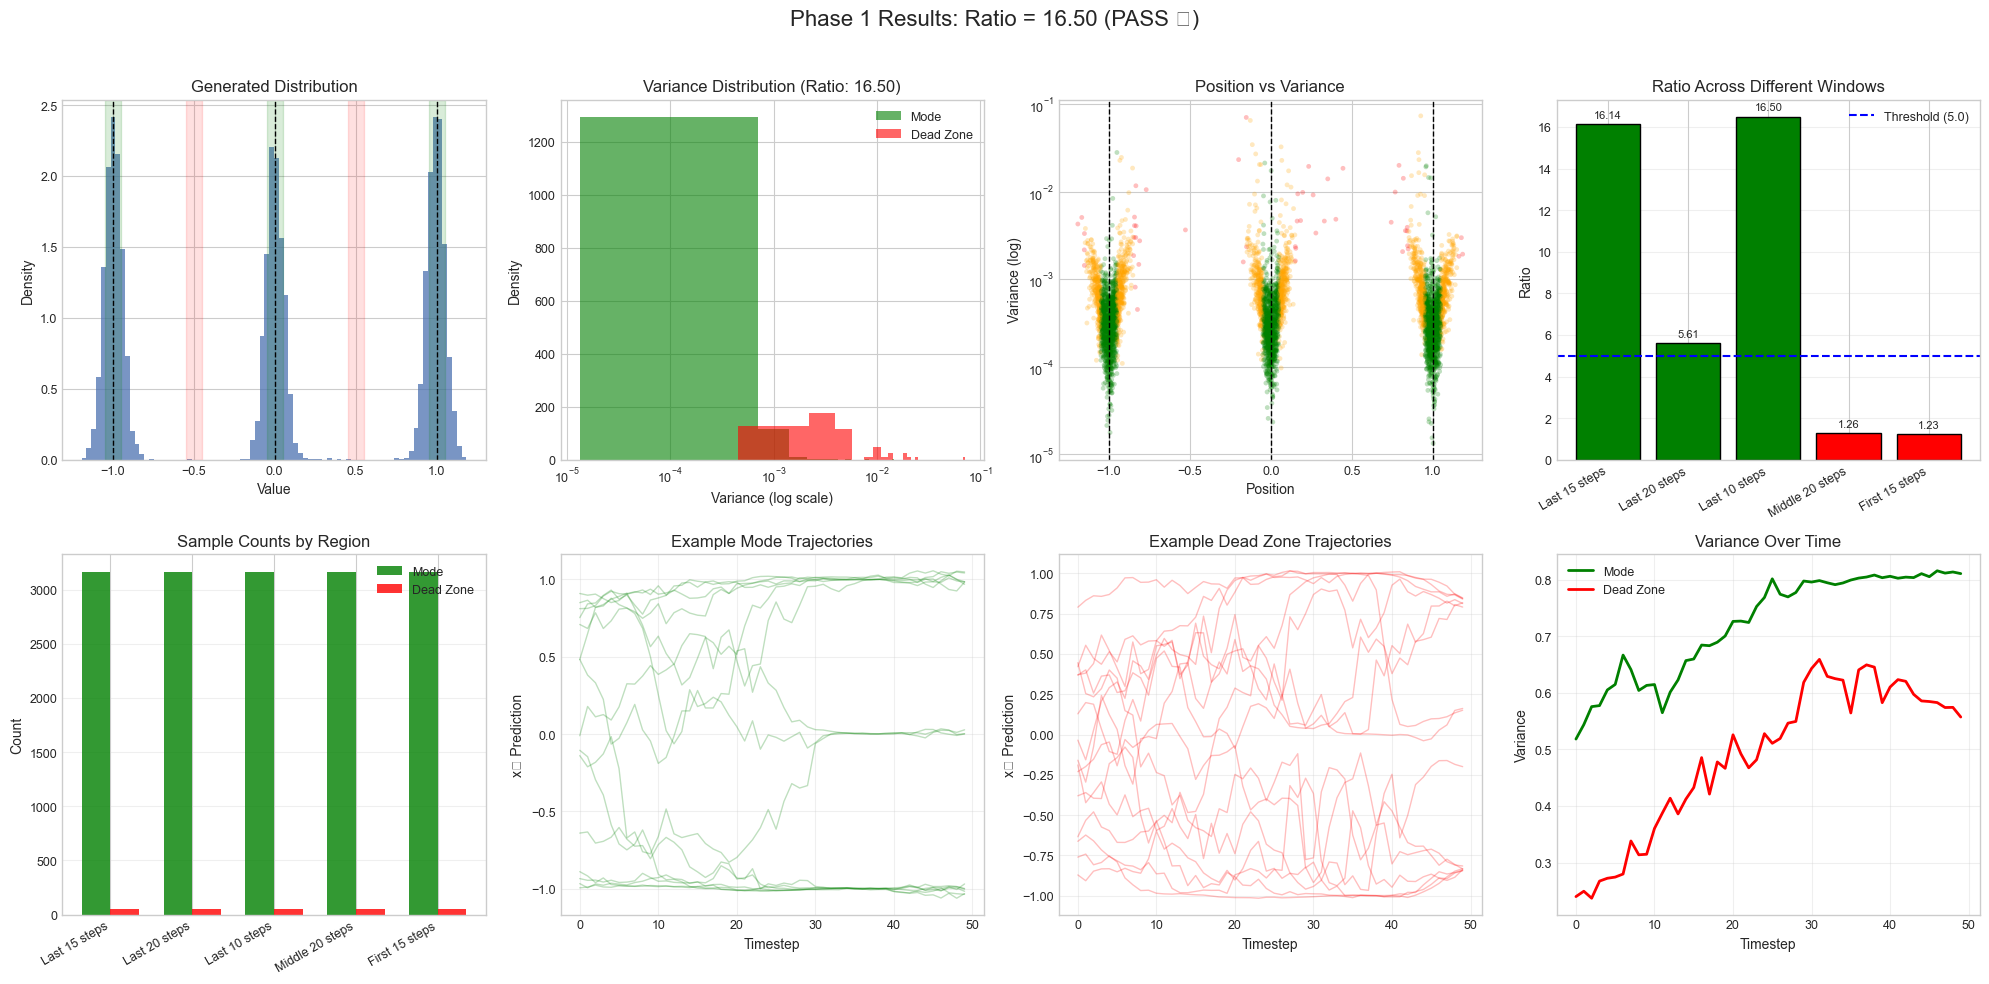

In [ ]:
best_variances = best_result['variances']
best_mode_vars = best_result['mode_vars']
best_dead_vars = best_result['dead_vars']
best_ratio = best_result['ratio']

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flatten()

ax1 = axs[0]

ax1.hist(
    final_samples,
    bins=80,
    density=True,
    alpha=0.75,
    color="#4C72B0"
)

for m in MEANS:
    ax1.axvline(m, color='black', linestyle='--', linewidth=1)
    ax1.axvspan(
        m - MODE_THRESHOLD,
        m + MODE_THRESHOLD,
        alpha=0.15,
        color='green'
    )

for i in range(len(MEANS) - 1):
    mid_point = (MEANS[i] + MEANS[i + 1]) / 2
    ax1.axvspan(mid_point - 0.05, mid_point + 0.05,
                alpha=0.12, color='red')

ax1.set_title("Generated Distribution")
ax1.set_xlabel("Value")
ax1.set_ylabel("Density")

ax2 = axs[1]

if best_mode_vars and best_dead_vars:
    ax2.hist(best_mode_vars, bins=40, alpha=0.6,
             label='Mode', density=True, color='green')
    ax2.hist(best_dead_vars, bins=40, alpha=0.6,
             label='Dead Zone', density=True, color='red')

ax2.set_xscale("log")
ax2.set_title(f"Variance Distribution (Ratio: {best_ratio:.2f})")
ax2.set_xlabel("Variance (log scale)")
ax2.set_ylabel("Density")
ax2.legend(frameon=False)

ax3 = axs[2]

colors = [
    'green' if get_region(x) == "Mode"
    else 'red' if get_region(x) == "DeadZone"
    else 'orange'
    for x in final_samples
]

ax3.scatter(
    final_samples,
    best_variances,
    alpha=0.25,
    s=12,
    c=colors,
    edgecolors='none'
)

for m in MEANS:
    ax3.axvline(m, color='black', linestyle='--', linewidth=1)

ax3.set_yscale("log")
ax3.set_title("Position vs Variance")
ax3.set_xlabel("Position")
ax3.set_ylabel("Variance (log)")

ax4 = axs[3]

window_names = [r['name'].split(' (')[0] for r in results]
ratios = [r['ratio'] for r in results]

colors_bar = ['green' if r > 5.0 else 'red' for r in ratios]

bars = ax4.bar(
    range(len(ratios)),
    ratios,
    color=colors_bar,
    edgecolor='black',
    linewidth=1
)

ax4.axhline(
    y=5.0,
    color='blue',
    linestyle='--',
    linewidth=1.5,
    label='Threshold (5.0)'
)

ax4.set_xticks(range(len(window_names)))
ax4.set_xticklabels(window_names, rotation=30, ha='right')
ax4.set_ylabel("Ratio")
ax4.set_title("Ratio Across Different Windows")
ax4.legend(frameon=False)
ax4.grid(axis='y', alpha=0.3)

for bar, ratio in zip(bars, ratios):
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.2,
        f'{ratio:.2f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

ax5 = axs[4]

n_modes = [r['n_mode'] for r in results]
n_deads = [r['n_dead'] for r in results]

x = np.arange(len(window_names))
width = 0.35

ax5.bar(
    x - width / 2,
    n_modes,
    width,
    label='Mode',
    color='green',
    alpha=0.8
)

ax5.bar(
    x + width / 2,
    n_deads,
    width,
    label='Dead Zone',
    color='red',
    alpha=0.8
)

ax5.set_xticks(x)
ax5.set_xticklabels(window_names, rotation=30, ha='right')
ax5.set_ylabel("Count")
ax5.set_title("Sample Counts by Region")
ax5.legend(frameon=False)
ax5.grid(axis='y', alpha=0.3)

ax6 = axs[5]

mode_indices = [
    i for i, x in enumerate(final_samples)
    if get_region(x) == "Mode"
][:15]

for idx in mode_indices:
    ax6.plot(
        trajectories[idx],
        alpha=0.25,
        color='green',
        linewidth=1
    )

ax6.set_title("Example Mode Trajectories")
ax6.set_xlabel("Timestep")
ax6.set_ylabel("x₀ Prediction")
ax6.grid(alpha=0.3)

ax7 = axs[6]

dead_indices = [
    i for i, x in enumerate(final_samples)
    if get_region(x) == "DeadZone"
][:15]

if dead_indices:
    for idx in dead_indices:
        ax7.plot(
            trajectories[idx],
            alpha=0.25,
            color='red',
            linewidth=1
        )
    ax7.set_title("Example Dead Zone Trajectories")
else:
    ax7.text(
        0.5, 0.5,
        "No Dead Zone Samples",
        ha='center',
        va='center',
        transform=ax7.transAxes,
        fontsize=11
    )
    ax7.set_title("Dead Zone Trajectories")

ax7.set_xlabel("Timestep")
ax7.set_ylabel("x₀ Prediction")
ax7.grid(alpha=0.3)

ax8 = axs[7]

if mode_indices:
    mode_var_over_time = np.var(
        [trajectories[i] for i in mode_indices[:50]],
        axis=0
    )
    ax8.plot(mode_var_over_time, label='Mode',
             color='green', linewidth=2)

if dead_indices:
    dead_var_over_time = np.var(
        [trajectories[i] for i in dead_indices[:50]],
        axis=0
    )
    ax8.plot(dead_var_over_time, label='Dead Zone',
             color='red', linewidth=2)

ax8.set_title("Variance Over Time")
ax8.set_xlabel("Timestep")
ax8.set_ylabel("Variance")
ax8.legend(frameon=False)
ax8.grid(alpha=0.3)

fig.suptitle(
    f'Phase 1 Results: Ratio = {best_ratio:.2f} '
    f'({"PASS" if best_ratio > 5.0 else "FAIL ✗"})',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('phase1_results_clean.png',
            dpi=200,
            bbox_inches='tight')

print("Visualization saved to: phase1_results_clean.png")

plt.show()